### PCA DADOS DO AR

A ideia, nesse primeiro momento, é verificar se é possível aplicar o PCA nos dados atuais. Para isso, vamos nos basear nos resultados do KMO e do teste da esfericidade de Bartlett

#### OBSERVAÇÕES IMPORTANTES:
Nesse primeiro momento, selecionei somente as seguintes features para o PCA:
'hum', 'pm10', 'pm25', 'pm1', 'NO2', 'CO', 'NH3', 'intTemp', 'extTemp', 'alt', 'Pres'
Quanto aos dados nulos, apenas "dropei" todas as colunas com valores nulos, perdendo cerca de 60% dos dados totais, futuramente vou testar outra abordagem para o preenchimento dessas lacunas.
Apliquei o PCA sobre a Matriz de Correlação.

In [54]:
# Importação de bibliotecas necessárias
# Remova o '#' e execute a linha para instalar as bibliotecas
# !pip install factor_analyzer numpy pandas matplotlib seaborn scikit-learn scipy mpl_axes_aligner

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mpl_axes_aligner
import seaborn as sns
import os
import itertools

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import chi2

from factor_analyzer.factor_analyzer import calculate_kmo
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

In [55]:
USER_DIR = os.getcwd()  # Diretório atual
DATA_PATH = os.path.join(USER_DIR, 'data', 'moqa.csv')  # Caminho para os dados
data = pd.read_csv(DATA_PATH)  # Carregando os dados do arquivo CSV

#### Breve análise dos dados:

In [56]:
print(data.shape)  # Exibindo o tamanho do DataFrame
print(data.info())  # Exibindo informações sobre o DataFrame
print(data.describe())  # Exibindo estatísticas descritivas do DataFrame
print('Quantidade de nulos: ', data.isnull().sum())  # Exibindo a contagem de valores nulos por coluna

(3861652, 33)
<class 'pandas.DataFrame'>
RangeIndex: 3861652 entries, 0 to 3861651
Data columns (total 33 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Unnamed: 0            int64  
 1   data_hora             str    
 2   createdTime           str    
 3   hum                   float64
 4   moqaID                str    
 5   alt                   float64
 6   pm25                  float64
 7   Pres                  float64
 8   CO                    float64
 9   O3                    float64
 10  NO2                   float64
 11  NH3                   float64
 12  pm10                  float64
 13  pm1                   float64
 14  intTemp               float64
 15  extTemp               float64
 16  pmsLog                int64  
 17  adsLog                int64  
 18  rtcLog                int64  
 19  bmeLog                int64  
 20  ccsLog                int64  
 21  msdLog                int64  
 22  erroLog               int64  
 23  Pont

In [57]:
data.head(10)  # Exibindo as primeiras 10 linhas do DataFrame

,Unnamed: 0,data_hora,createdTime,hum,moqaID,alt,pm25,Pres,CO,O3,...,Ponto,Zona,Latitude,Longitude,Bairro,Referência,Localizador Google,Status (Monitor),Infraestrutura MOB,Status (Transmissão)
0,0,2023-08-22 11:31:14+00:00,2023-08-22T14:46:28.139743Z,50.67538,DD34F0,12.24787,6.21875,101177.96875,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
1,1,2023-08-22 11:31:46+00:00,2023-08-22T14:46:56.045103Z,48.54282,DD34F0,12.16762,7.50000,101178.93750,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
2,2,2023-08-22 11:32:14+00:00,2023-08-22T14:47:23.798216Z,47.78475,DD34F0,12.29149,9.18750,101177.44531,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
3,3,2023-08-22 11:32:42+00:00,2023-08-22T14:47:51.820758Z,47.77321,DD34F0,12.44472,11.22656,101175.61719,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
4,4,2023-08-22 11:33:09+00:00,2023-08-22T14:48:19.477544Z,47.95964,DD34F0,12.49085,11.30000,101175.06250,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
5,5,2023-08-22 11:33:37+00:00,2023-08-22T14:48:47.264201Z,49.08266,DD34F0,12.57050,10.71354,101174.11719,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
6,6,2023-08-22 11:34:05+00:00,2023-08-22T14:49:14.991072Z,49.12064,DD34F0,12.67994,9.95536,101172.82031,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
7,7,2023-08-22 11:34:33+00:00,2023-08-22T14:49:46.120138Z,48.86996,DD34F0,12.85130,9.44141,101170.75781,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
8,8,2023-08-22 11:35:04+00:00,2023-08-22T14:50:13.772152Z,48.53812,DD34F0,13.01833,9.17014,101168.74219,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
9,9,2023-08-22 11:35:31+00:00,2023-08-22T14:50:41.462495Z,48.22467,DD34F0,13.14409,8.91277,101167.23438,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)


In [58]:
data = data.drop(['Unnamed: 0', 'O3'], axis=1) # Removendo colunas desnecessárias do DataFrame (no caso O3 era uma coluna de NaN)
data.head()

,data_hora,createdTime,hum,moqaID,alt,pm25,Pres,CO,NO2,NH3,...,Ponto,Zona,Latitude,Longitude,Bairro,Referência,Localizador Google,Status (Monitor),Infraestrutura MOB,Status (Transmissão)
0,2023-08-22 11:31:14+00:00,2023-08-22T14:46:28.139743Z,50.67538,DD34F0,12.24787,6.21875,101177.96875,NaN,0.096762,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
1,2023-08-22 11:31:46+00:00,2023-08-22T14:46:56.045103Z,48.54282,DD34F0,12.16762,7.50000,101178.93750,NaN,0.084920,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
2,2023-08-22 11:32:14+00:00,2023-08-22T14:47:23.798216Z,47.78475,DD34F0,12.29149,9.18750,101177.44531,NaN,0.083098,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
3,2023-08-22 11:32:42+00:00,2023-08-22T14:47:51.820758Z,47.77321,DD34F0,12.44472,11.22656,101175.61719,NaN,0.077328,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
4,2023-08-22 11:33:09+00:00,2023-08-22T14:48:19.477544Z,47.95964,DD34F0,12.49085,11.30000,101175.06250,NaN,0.076418,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)


In [59]:
# Selecionando 10 features para análise de PCA
pca_features = ['hum', 'pm10', 'pm25', 'pm1', 'NO2', 'CO', 'NH3', 'intTemp', 'extTemp', 'Pres']
X = data[pca_features]  # Selecionando as features do DataFrame para PCA
X.isnull().sum()  # Verificando a quantidade de valores nulos nas features selecionadas
X.dropna(inplace=True)  # Removendo linhas com valores nulos

In [60]:
X.describe()  # Exibindo estatísticas descritivas das features selecionadas

,hum,pm10,pm25,pm1,NO2,CO,NH3,intTemp,extTemp,Pres
count,2.080369e+06,2.080369e+06,2.080369e+06,2.080369e+06,2.080369e+06,2.080369e+06,2.080369e+06,2.080369e+06,2.080369e+06,2.080369e+06
mean,5.944231e+01,1.013631e+01,7.926673e+00,3.916247e+00,1.749396e-01,3.045974e+01,1.771524e+01,2.771852e+01,2.895899e+01,2.093785e+04
std,2.485603e+01,8.301284e+00,6.867632e+00,4.288578e+00,1.521265e-01,1.473938e+01,6.913740e+00,2.082048e+01,2.394704e+00,4.017784e+04
min,2.500000e-01,0.000000e+00,0.000000e+00,0.000000e+00,5.484921e-03,2.441406e-05,4.578603e-03,-1.463301e+02,2.059583e+01,-2.022782e+02
25%,4.559199e+01,4.533330e+00,3.215820e+00,9.000000e-01,7.422114e-02,1.859103e+01,1.327043e+01,2.970616e+01,2.714583e+01,1.009047e+03
50%,5.871237e+01,8.067450e+00,6.192900e+00,2.698920e+00,9.348267e-02,3.316385e+01,1.895413e+01,3.096932e+01,2.842161e+01,1.011832e+03
75%,6.781937e+01,1.313333e+01,1.050000e+01,5.266670e+00,2.000334e-01,4.393289e+01,2.284242e+01,3.447713e+01,3.085208e+01,1.016334e+03
max,1.000000e+02,3.911000e+02,3.306667e+02,1.609667e+02,1.464401e+00,4.999982e+01,4.999747e+01,1.363375e+02,3.765955e+01,9.869334e+05


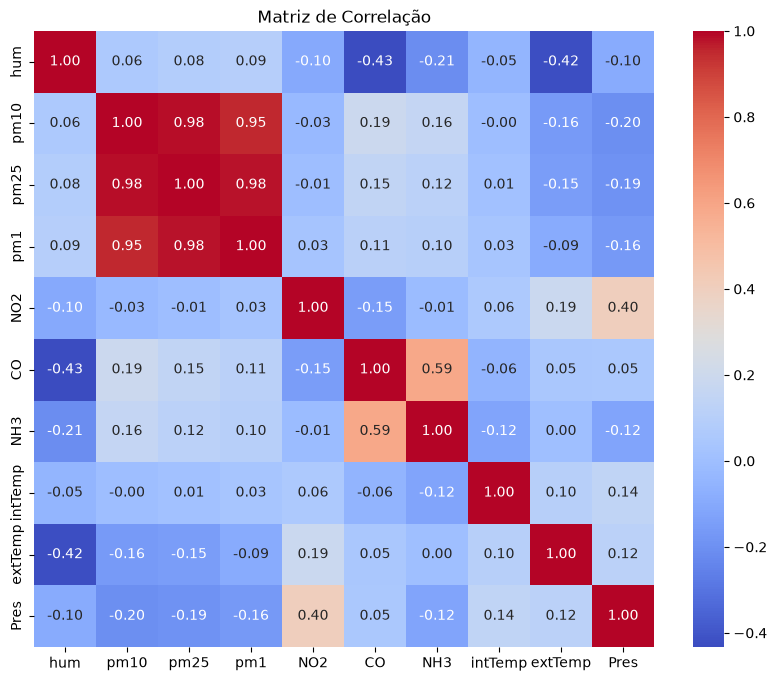

In [61]:
# Plotando a matriz de correlação das features selecionadas
corr = X.corr() # Essa função é muito massa kkkkkk, agiliza MUITO o processo
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlação")
plt.show()


#### Análise KMO e Esferecidade de Bartlett

In [62]:
def cronbach_alpha(X):
    k = X.shape[1]
    variancias = X.var(axis=0, ddof=1)
    soma_variancias = variancias.sum()
    soma_itens = X.sum(axis=1)
    variancia_total = soma_itens.var(ddof=1)
    alpha = (k / (k - 1)) * (
        1 - (soma_variancias / variancia_total)
    )
    
    return alpha

alpha = cronbach_alpha(X)

print(f"Alfa de Cronbach: {alpha:.4f}")

# Analisar isso

Alfa de Cronbach: -0.0002


In [63]:
# KMO
# Geral
kmo_all, kmo_model = calculate_kmo(X)
print(f"KMO: {kmo_model:.4f}")
# Individual
kmo_individual = pd.Series(
    kmo_all,
    index=X.columns
)
kmo_individual.sort_values(ascending=False)

# Como KMO > 0.5, está uma situação aceitável para realizar a PCA.

KMO: 0.5872


pm10       0.695752
pm1        0.662159
intTemp    0.647018
pm25       0.582630
hum        0.545058
NH3        0.496365
CO         0.485072
extTemp    0.482021
Pres       0.467866
NO2        0.391382
dtype: float64

In [64]:
# Esfericidade de Bartlett
chi_square_value, p_value = calculate_bartlett_sphericity(X)

print(f"Qui-quadrado: {chi_square_value:.4f}")
print(f"Qui: {np.sqrt(chi_square_value):.4f}")
print(f"p-valor: {p_value:.6f}")


Qui-quadrado: 17833497.4823
Qui: 4222.9726
p-valor: 0.000000


### Aplicação do PCA

In [65]:
# Padronização dos dados:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)
X_scaled.head()

,hum,pm10,pm25,pm1,NO2,CO,NH3,intTemp,extTemp,Pres
104,-0.143058,0.039925,-0.090311,-0.341521,0.274536,-0.075089,-1.715053,0.262599,0.165725,1.994215
106,-0.146141,-0.074709,-0.178774,-0.416739,0.290504,-0.135073,-1.715053,0.263950,0.191123,1.994233
108,-0.152198,-0.113569,-0.207739,-0.431781,0.252580,-0.161963,-1.717255,0.265269,0.197716,1.994236
121,-0.274249,0.139015,0.029465,-0.318954,0.019044,-0.246767,-1.712850,0.299033,0.311793,1.993927
123,-0.285159,-0.051394,-0.123190,-0.394172,0.046988,-0.224015,-1.712850,0.303936,0.349259,1.993925


In [66]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled) 
autovalores = pca.explained_variance_ # Calcula os autovalores
print(autovalores) # Exibe os autovalores
variancia_explicada = pca.explained_variance_ratio_ # Calcula a variância
print(variancia_explicada) # Exibe a variância explicada

tabela_pca = pd.DataFrame({
    "Componente": range(1, len(autovalores) + 1),
    "Autovalor": autovalores,
    "% Variância": variancia_explicada * 100,
    "% Variância Acumulada": np.cumsum(variancia_explicada) * 100
}) # Cria uma tabela com os resultados das variancias explicadas e acumuladas do PCA

tabela_pca

# Adotando o critério autovalor > 1, podemos observar que os 4 primeiros componentes principais são significativos,
# pois possuem autovalores maiores que 1. Além disso, a variância explicada acumulada pelos 4 primeiros componentes é de aproximadamente 80%, 
# o que indica que esses componentes retêm a maior parte da informação presente nos dados originais.

[3.11537106 1.91238348 1.56015774 1.03198498 0.91846648 0.65459364
 0.49418779 0.2652867  0.04154753 0.0060254 ]
[0.31153696 0.19123826 0.1560157  0.10319845 0.0918466  0.06545933
 0.04941875 0.02652866 0.00415475 0.00060254]


,Componente,Autovalor,% Variância,% Variância Acumulada
0,1,3.115371,31.153696,31.153696
1,2,1.912383,19.123826,50.277521
2,3,1.560158,15.601570,65.879091
3,4,1.031985,10.319845,76.198936
4,5,0.918466,9.184660,85.383596
5,6,0.654594,6.545933,91.929530
6,7,0.494188,4.941875,96.871405
7,8,0.265287,2.652866,99.524271
8,9,0.041548,0.415475,99.939746
9,10,0.006025,0.060254,100.000000


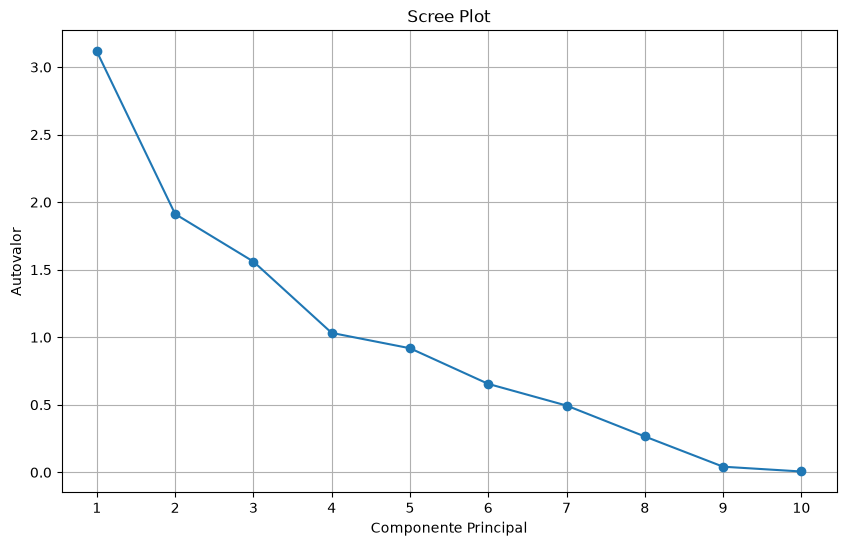

In [67]:
# Scree plot
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(autovalores) + 1),
    autovalores,
    marker="o"
)
plt.xlabel("Componente Principal")
plt.ylabel("Autovalor")
plt.title("Scree Plot")
plt.xticks(range(1, len(autovalores) + 1))
plt.grid()

plt.show()

In [68]:
# Critério de Kaiser:
componentes_kaiser = np.sum(autovalores > 1)
print(
    f"Número de componentes com autovalor > 1: "
    f"{componentes_kaiser}"
)

# Verificando a variância acumulada
n_componentes = componentes_kaiser
variancia_acumulada = (
    np.sum(variancia_explicada[:n_componentes]) * 100
)

print(
    f"As {n_componentes} componentes explicam "
    f"{variancia_acumulada:.2f}% da variância."
)

Número de componentes com autovalor > 1: 4
As 4 componentes explicam 76.20% da variância.


In [69]:
# PCA:
n_componentes = 4
pca_final = PCA(n_components=n_componentes)
X_pca_final = pca_final.fit_transform(X_scaled)

# Transformando o resultado em um df
df_pca = pd.DataFrame(
    X_pca_final,
    columns=[
        f"PC{i+1}"
        for i in range(n_componentes)
    ],
    index=X.index
)
df_pca.head()

,PC1,PC2,PC3,PC4
104,-0.868512,-0.413330,1.719107,-0.262457
106,-1.034620,-0.428300,1.710266,-0.255541
108,-1.083409,-0.440116,1.686656,-0.231428
121,-0.771186,-0.414374,1.714706,-0.006095
123,-1.005587,-0.369865,1.682212,-0.007895


In [70]:
# Variância explicada pelos componentes principais
variancia_final = pca_final.explained_variance_ratio_

for i, variancia in enumerate(variancia_final, start=1):
    print(
        f"PC{i}: {variancia * 100:.2f}%"
    )

print(
    f"\nVariância acumulada: "
    f"{np.sum(variancia_final) * 100:.2f}%"
)

PC1: 31.15%
PC2: 19.12%
PC3: 15.60%
PC4: 10.32%

Variância acumulada: 76.20%


In [71]:
# Loadings das componentes principais
loadings = (
    pca_final.components_.T
    * np.sqrt(pca_final.explained_variance_)
)

# Visualização tabela:
loadings_df = pd.DataFrame(
    loadings,
    index=X.columns,
    columns=[
        f"PC{i+1}"
        for i in range(n_componentes)
    ]
)

loadings_df

,PC1,PC2,PC3,PC4
hum,0.096763,-0.781727,-0.131219,-0.269266
pm10,0.975859,-0.014022,0.142328,0.012524
pm25,0.977184,-0.050194,0.182631,0.024353
pm1,0.954189,-0.054625,0.236809,0.037460
NO2,-0.105629,0.117839,0.721239,-0.446893
CO,0.254321,0.783655,-0.277931,-0.125633
NH3,0.254553,0.646294,-0.361586,-0.286263
intTemp,-0.037835,-0.009399,0.429536,0.510329
extTemp,-0.228608,0.467234,0.396005,0.453661
Pres,-0.306619,0.177466,0.603119,-0.440046


In [72]:
# Variáveis mais importantes para cada componente principal
for componente in loadings_df.columns:
    print(f"\n{componente}")
    print(
        loadings_df[componente]
        .abs()
        .sort_values(ascending=False)
    )

for componente in loadings_df.columns:
    
    print(f"\n - {componente}")
    
    print(
        loadings_df[componente]
        .sort_values(
            key=abs,
            ascending=False
        )
    )
# PC1: pm25, pm10, pm1
# PC2: CO, hum, NH3
# PC3: NO2, Pres, intTemp
# PC4: intTemp, extTemp, NO2


PC1
pm25       0.977184
pm10       0.975859
pm1        0.954189
Pres       0.306619
NH3        0.254553
CO         0.254321
extTemp    0.228608
NO2        0.105629
hum        0.096763
intTemp    0.037835
Name: PC1, dtype: float64

PC2
CO         0.783655
hum        0.781727
NH3        0.646294
extTemp    0.467234
Pres       0.177466
NO2        0.117839
pm1        0.054625
pm25       0.050194
pm10       0.014022
intTemp    0.009399
Name: PC2, dtype: float64

PC3
NO2        0.721239
Pres       0.603119
intTemp    0.429536
extTemp    0.396005
NH3        0.361586
CO         0.277931
pm1        0.236809
pm25       0.182631
pm10       0.142328
hum        0.131219
Name: PC3, dtype: float64

PC4
intTemp    0.510329
extTemp    0.453661
NO2        0.446893
Pres       0.440046
NH3        0.286263
hum        0.269266
CO         0.125633
pm1        0.037460
pm25       0.024353
pm10       0.012524
Name: PC4, dtype: float64

 - PC1
pm25       0.977184
pm10       0.975859
pm1        0.954189
Pres    

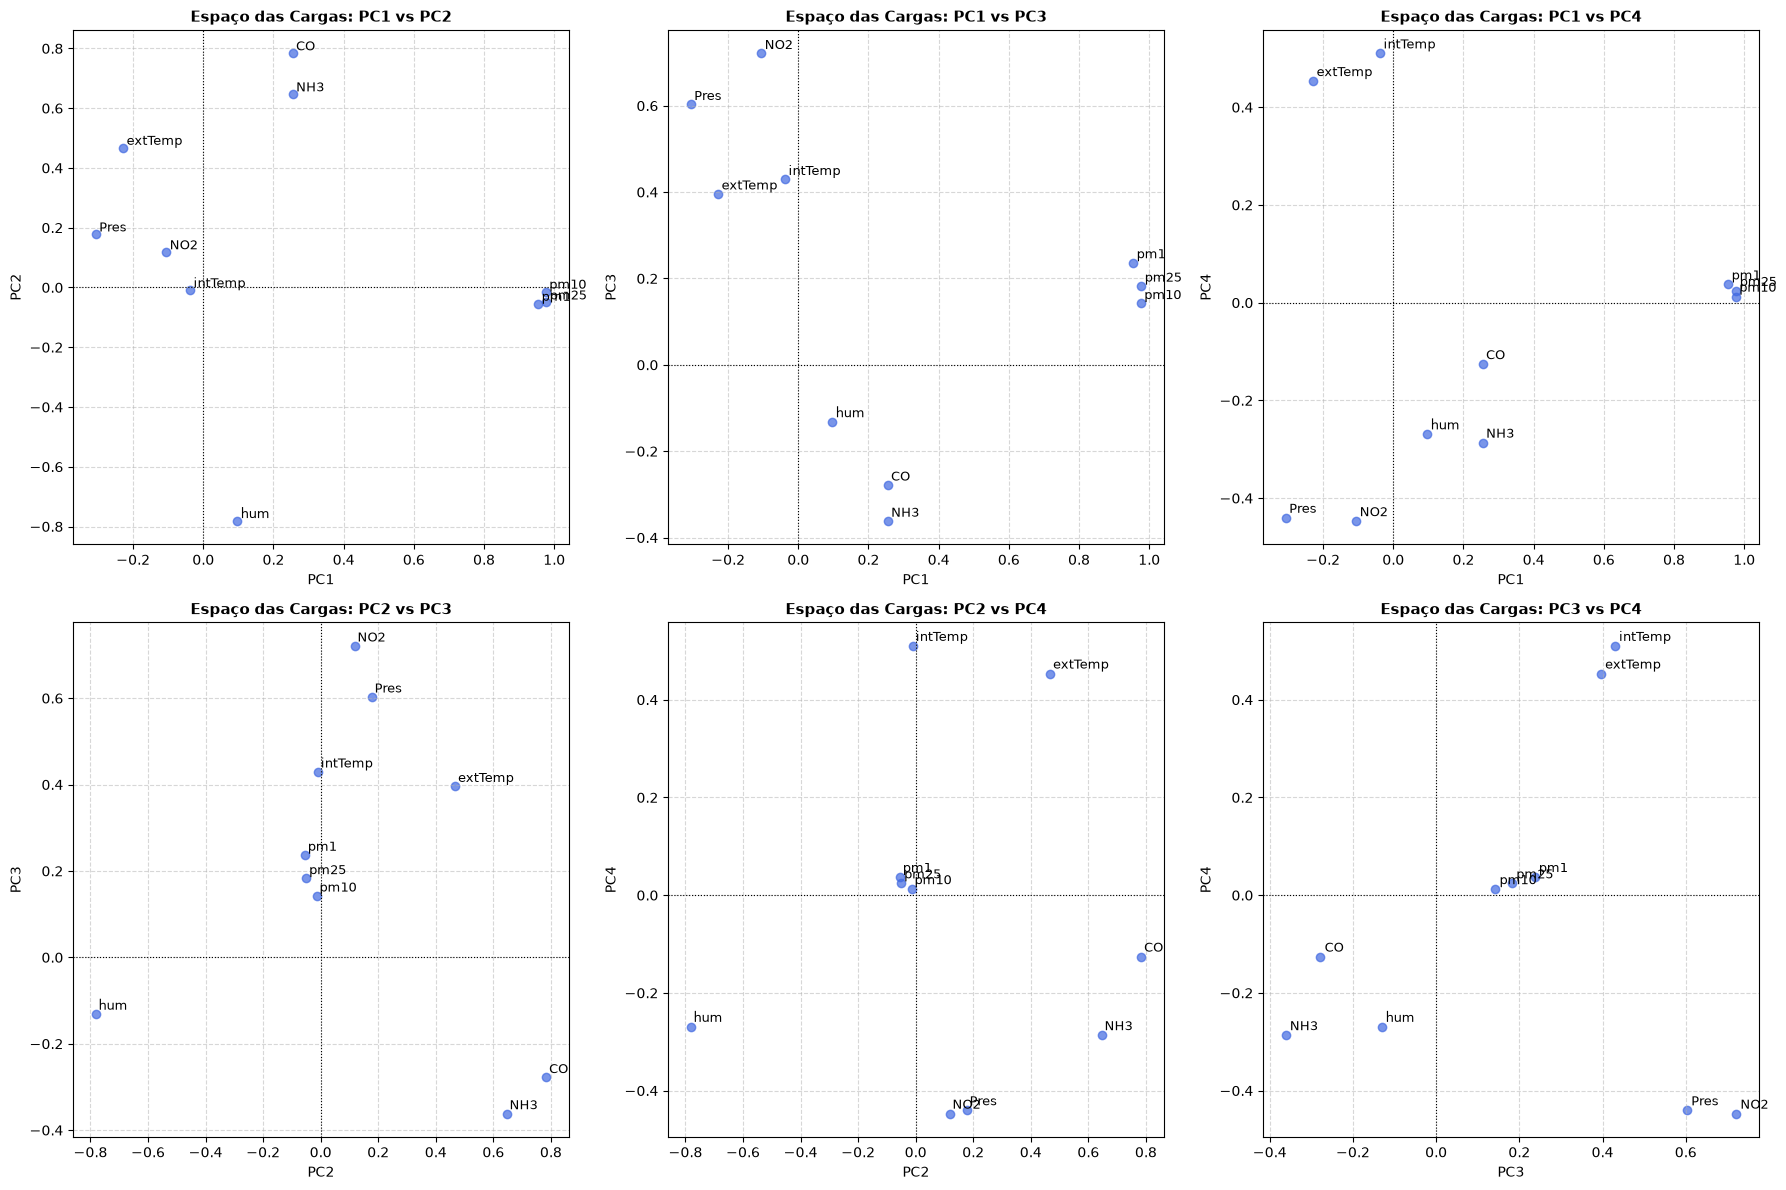

In [73]:
# Definir os 4 componentes e gerar automaticamente os 6 pares possíveis
componentes = ["PC1", "PC2", "PC3", "PC4"]
pares = list(itertools.combinations(componentes, 2))

# Criar uma matriz de subplots 2x3 (6 gráficos)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()  # Achata a matriz 2D para um vetor linear de 6 posições

# Loop para plotar cada par em seu respectivo gráfico
for i, (pc_x, pc_y) in enumerate(pares):
    ax = axes[i]

    # Gráfico de dispersão idêntico ao seu original
    ax.scatter(loadings_df[pc_x], loadings_df[pc_y], color="royalblue", alpha=0.7)

    # Loop para adicionar os textos com um pequeno ajuste (+0.01) para não sobrepor o ponto
    for variavel in loadings_df.index:
        ax.text(
            loadings_df.loc[variavel, pc_x] + 0.01,
            loadings_df.loc[variavel, pc_y] + 0.01,
            variavel,
            fontsize=9,
        )

    # Linhas de referência cruzando o zero
    ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
    ax.axvline(0, color="black", linewidth=0.8, linestyle=":")

    # Rótulos dinâmicos baseados no par atual
    ax.set_xlabel(pc_x, fontsize=10)
    ax.set_ylabel(pc_y, fontsize=10)
    ax.set_title(f"Espaço das Cargas: {pc_x} vs {pc_y}", fontsize=11, weight="bold")
    ax.grid(True, linestyle="--", alpha=0.5)

# Ajusta automaticamente o espaçamento entre os subplots
plt.tight_layout()
plt.show()


In [74]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
autovalores = pca.explained_variance_
variancia_explicada = pca.explained_variance_ratio_
tabela_pca = pd.DataFrame({
    "Componente": range(1, len(autovalores) + 1),
    "Autovalor": autovalores,
    "% Variância": variancia_explicada * 100,
    "% Variância Acumulada": np.cumsum(variancia_explicada) * 100
})

tabela_pca

,Componente,Autovalor,% Variância,% Variância Acumulada
0,1,3.115371,31.153696,31.153696
1,2,1.912383,19.123826,50.277521
2,3,1.560158,15.601570,65.879091
3,4,1.031985,10.319845,76.198936
4,5,0.918466,9.184660,85.383596
5,6,0.654594,6.545933,91.929530
6,7,0.494188,4.941875,96.871405
7,8,0.265287,2.652866,99.524271
8,9,0.041548,0.415475,99.939746
9,10,0.006025,0.060254,100.000000


### Biplot dos Componentes Principais

O **Biplot** projeta simultaneamente as observações (escores no espaço reduzido) e os vetores das variáveis originais (cargas/loadings), permitindo interpretar a direção e magnitude da influência de cada sensor em relação à distribuição amostral.

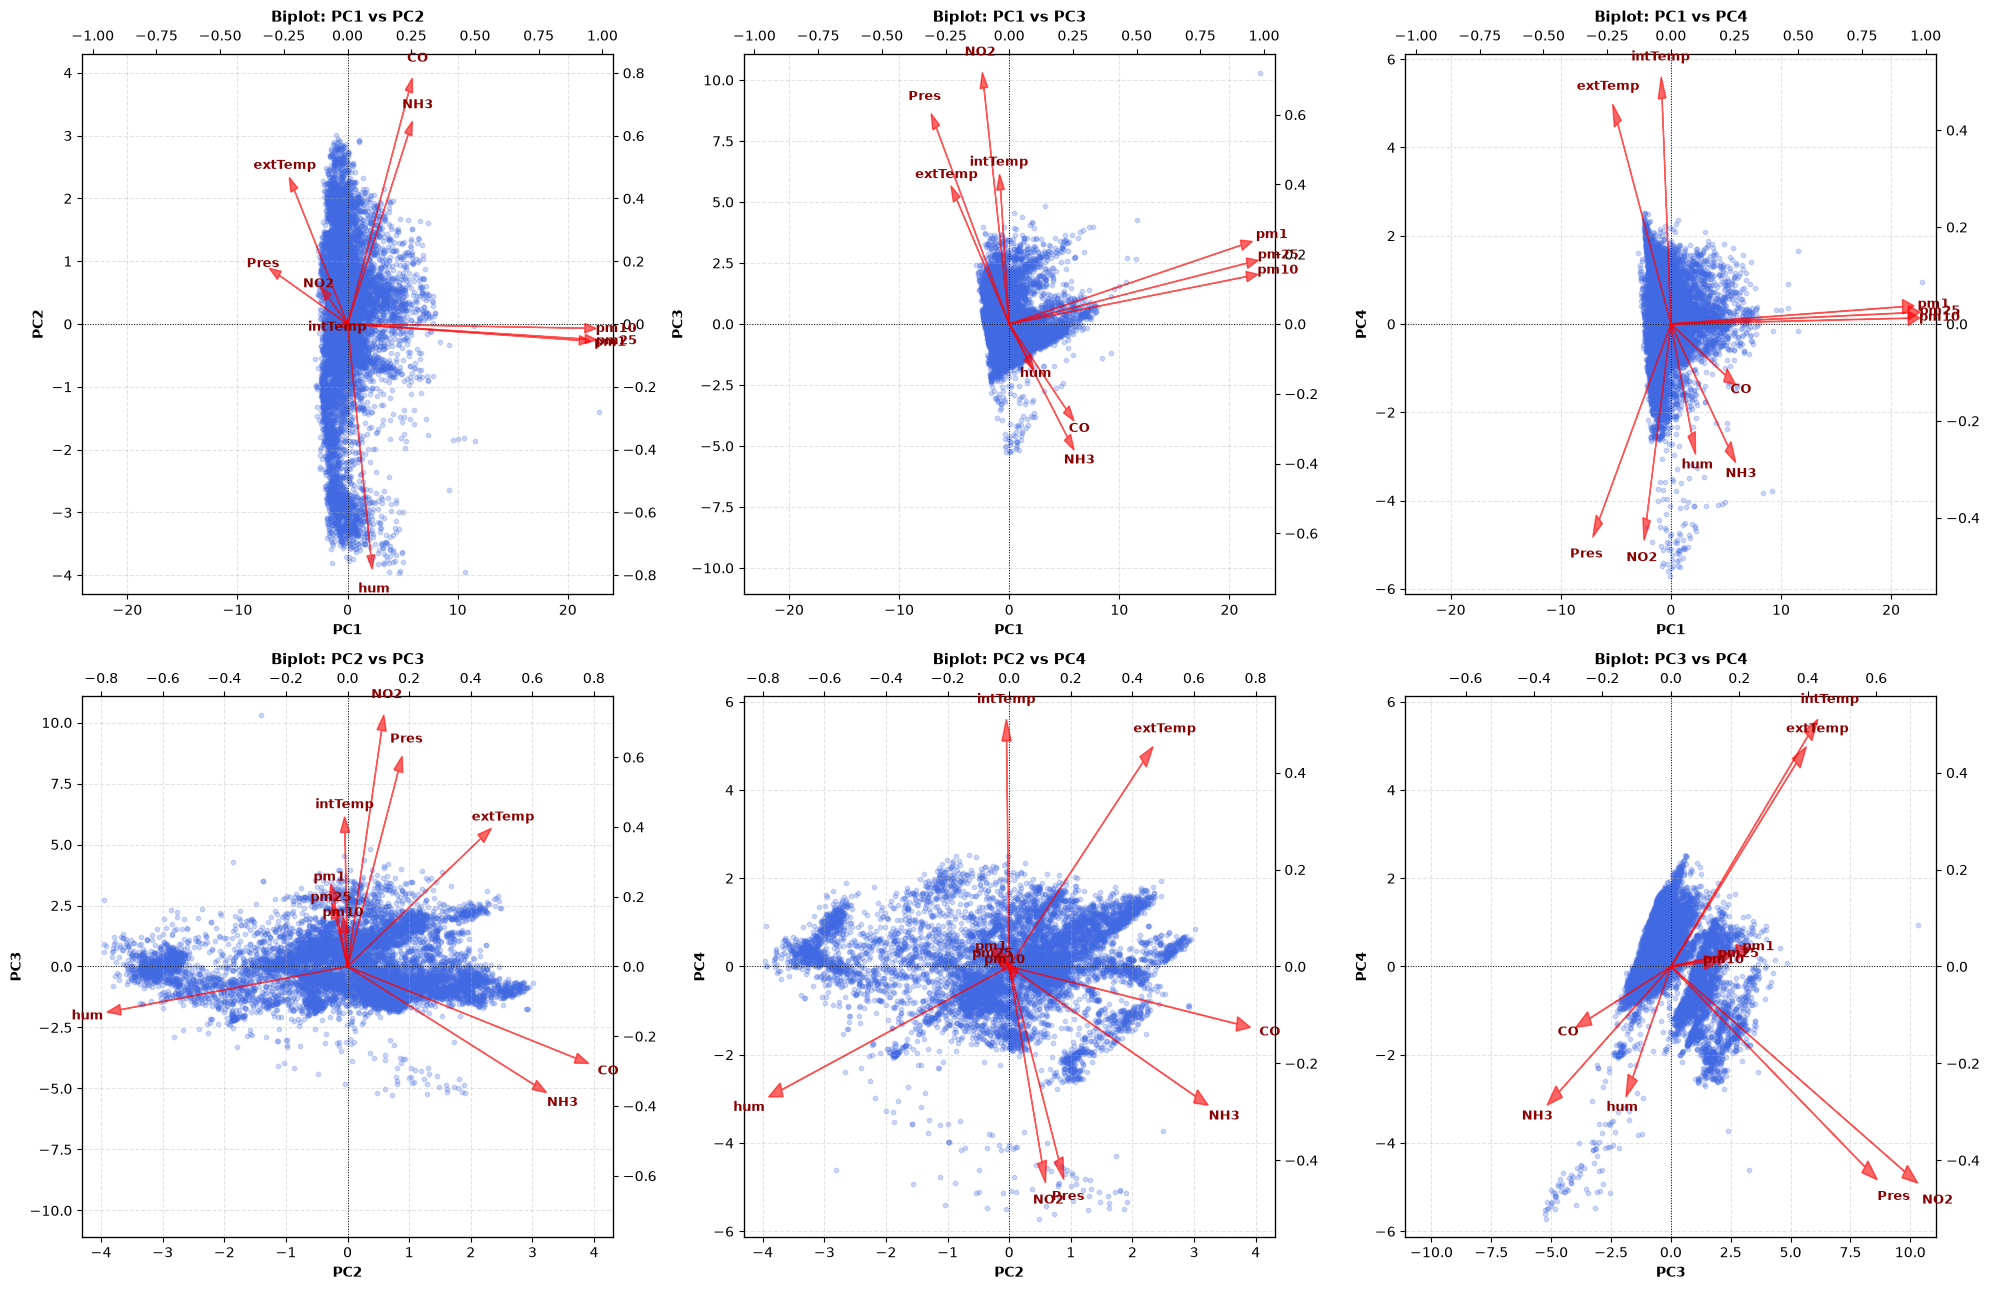

In [75]:
def biplot_multicomponentes(dfScores: pd.DataFrame, dfLoadings: pd.DataFrame, componentes: list = ["PC1", "PC2", "PC3", "PC4"], sample_size: int = 10000) -> None:
    # Garante que dfLoadings tenha os componentes no índice
    if componentes[0] in dfLoadings.columns and componentes[0] not in dfLoadings.index:
        dfLoadings = dfLoadings.T
    
    # Amostragem para visualização fluida com grandes volumes de dados
    if len(dfScores) > sample_size:
        dfScores_sample = dfScores.sample(n=sample_size, random_state=42)
    else:
        dfScores_sample = dfScores
        
    pares = list(itertools.combinations(componentes, 2))
    
    # Cria matriz 2x3 de subplots (6 combinações)
    fig, axes = plt.subplots(2, 3, figsize=(20, 13))
    axes = axes.flatten()
    
    font = {
        'color': 'darkred',
        'weight': 'bold',
        'size': 9,
    }
    
    for i, (pc_x, pc_y) in enumerate(pares):
        ax = axes[i]
        
        # 1. Gráfico de Scores (Observações)
        ax.scatter(dfScores_sample[pc_x].values, dfScores_sample[pc_y].values, color='royalblue', alpha=0.25, s=10)
        ax.set_xlabel(pc_x, fontsize=10, fontweight='bold')
        ax.set_ylabel(pc_y, fontsize=10, fontweight='bold')
        ax.set_title(f"Biplot: {pc_x} vs {pc_y}", fontsize=11, fontweight='bold')
        ax.grid(True, linestyle="--", alpha=0.35)
        
        # 2. Segundo conjunto de eixos para os Loadings (Cargas)
        ax2 = ax.twinx().twiny()
        
        # 3. Gráfico dos vetores de carga
        for col in dfLoadings.columns:
            tipx = dfLoadings.loc[pc_x, col]
            tipy = dfLoadings.loc[pc_y, col]
            ax2.arrow(0, 0, tipx, tipy, color='r', alpha=0.6, head_width=0.03, length_includes_head=True)
            ax2.text(tipx * 1.08, tipy * 1.08, col, fontdict=font, ha='center', va='center')
        
        # Linhas de referência cruzando o zero
        ax.axhline(0, color="black", linewidth=0.7, linestyle=":")
        ax.axvline(0, color="black", linewidth=0.7, linestyle=":")
        
        # Alinha a origem (0, 0) de ax e ax2 no centro do gráfico
        mpl_axes_aligner.align.xaxes(ax, 0, ax2, 0, 0.5)
        mpl_axes_aligner.align.yaxes(ax, 0, ax2, 0, 0.5)
        
    plt.tight_layout()
    plt.show()

# Execução da função adaptada para os 4 componentes
biplot_multicomponentes(df_pca, loadings_df)


Função acima extraída do vídeo:
https://www.youtube.com/watch?v=EFyNzAkJ2P0

Repositório:
https://github.com/insidelearningmachines/Blog/blob/main/%5BVideo%5D%20PCA_Biplot.ipynb

Obs: A função foi adaptada pois a original foi feita para apenas 2 componentes